# 🚗⚡ Tesla Deliveries & Production — End-to-End ML Pipeline
### Data Science Internship — Week 2 Assignment

| Step | Description |
|------|-------------|
| 1️⃣ Preprocessing | Cleaning, date parsing, type fixes |
| 2️⃣ EDA | Trends, seasonality, distributions, correlations |
| 3️⃣ Feature Engineering | Lags, rolling stats, ratios, cyclical features |
| 4️⃣ Regression Modeling | 5 models trained and compared |
| 5️⃣ Hyperparameter Tuning | GridSearchCV with TimeSeriesSplit |
| 6️⃣ Time Series Forecasting | SARIMA model with future predictions |

In [1]:
import pandas as pd
import numpy as np
import os

# ── Auto-detect CSV file path (works on any Kaggle dataset) ──
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            print(f'✅ Found: {csv_path}')
            break

df = pd.read_csv(csv_path)

# Basic info
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

✅ Found: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data types:
 Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

First 5 rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
# ── Check for duplicates ──────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# ── Unique values in categorical columns ─────────────────────
cat_cols = ["Region", "Model", "Source_Type"]
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):", df[col].unique())

Duplicate rows: 0

Region (4 unique): ['Europe' 'Asia' 'North America' 'Middle East']

Model (5 unique): ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']

Source_Type (3 unique): ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [3]:
# ── Numeric column ranges (sanity check) ─────────────────────
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]

for col in num_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}")

# ── Year & Month coverage ─────────────────────────────────────
print("\nYear range:", df["Year"].min(), "→", df["Year"].max())
print("Months present:", sorted(df["Month"].unique()))
print("Total year-month combinations:", df.groupby(["Year","Month"]).ngroups)

Estimated_Deliveries: min=48, max=25704, mean=9922.20
Production_Units: min=50, max=28939, mean=10655.85
Avg_Price_USD: min=50003.7, max=119965.36, mean=84907.34
Battery_Capacity_kWh: min=60, max=120, mean=87.06
Range_km: min=330, max=719, mean=500.26
CO2_Saved_tons: min=3.07, max=2548.55, mean=744.08
Charging_Stations: min=3002, max=14996, mean=8932.13

Year range: 2015 → 2025
Months present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Total year-month combinations: 132


In [4]:
# ── Markdown ──────────────────────────────────────────────────
# STEP 2 — PREPROCESSING
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── 2.1 Create datetime column from Year + Month ──────────────
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(day=1))
df = df.sort_values("Date").reset_index(drop=True)

print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("Shape:", df.shape)
df.head()

Date range: 2015-01-01 00:00:00 → 2025-12-01 00:00:00
Shape: (2640, 13)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


In [5]:
# ── 2.2 Check & fill missing values ──────────────────────────
print("Missing values before fix:")
print(df.isnull().sum())

# Fill numeric nulls with median
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical nulls with mode
cat_cols = ["Region", "Model", "Source_Type"]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after fix:")
print(df.isnull().sum())
print("\n✅ No missing values!")


Missing values before fix:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64

Missing values after fix:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64

✅ No missing values!


In [6]:
# ── 2.3 Label encode Region and Model ────────────────────────
le = LabelEncoder()
df["Region_enc"] = le.fit_transform(df["Region"])
df["Model_enc"]  = le.fit_transform(df["Model"])

# Print mappings
for col in ["Region", "Model"]:
    enc_col = col + "_enc"
    mapping = dict(zip(df[col], df[enc_col]))
    print(f"{col} encoding: {mapping}")

# ── 2.4 Ordinal encode Source_Type ───────────────────────────
source_order = {
    "Official (Quarter)":   2,
    "Estimated (Region)":   1,
    "Interpolated (Month)": 0
}
df["Source_Type_enc"] = df["Source_Type"].map(source_order)
print("\nSource_Type encoding:", source_order)
print("\n✅ Encoding done!")
df.head(3)

Region encoding: {'Asia': 0, 'Middle East': 2, 'North America': 3, 'Europe': 1}
Model encoding: {'Model Y': 4, 'Model 3': 1, 'Cybertruck': 0, 'Model S': 2, 'Model X': 3}

Source_Type encoding: {'Official (Quarter)': 2, 'Estimated (Region)': 1, 'Interpolated (Month)': 0}

✅ Encoding done!


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Region_enc,Model_enc,Source_Type_enc
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,0,4,2
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,2,1,1
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,2,0,0


In [7]:
# ── 2.5 Scale numeric features ───────────────────────────────
scale_cols = [
    "Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaled columns — mean should be ~0, std ~1:")
print(df_scaled[scale_cols].describe().loc[["mean","std"]].round(3))

# ── 2.6 Final cleaned dataframe summary ──────────────────────
print("\n✅ Final columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head(3)

Scaled columns — mean should be ~0, std ~1:
      Estimated_Deliveries  Production_Units  Avg_Price_USD  \
mean                   0.0              -0.0           -0.0   
std                    1.0               1.0            1.0   

      Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Charging_Stations  
mean                  -0.0       0.0             0.0               -0.0  
std                    1.0       1.0             1.0                1.0  

✅ Final columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Region_enc', 'Model_enc', 'Source_Type_enc']
Shape: (2640, 16)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Region_enc,Model_enc,Source_Type_enc
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,0,4,2
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,2,1,1
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,2,0,0


## 📊 Step 3 — Exploratory Data Analysis (EDA)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
print("✅ Plotting libraries ready!")

✅ Plotting libraries ready!


/tmp/ipykernel_16/2938199924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[0], palette="Set2")
/tmp/ipykernel_16/2938199924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[1], palette="Set2")


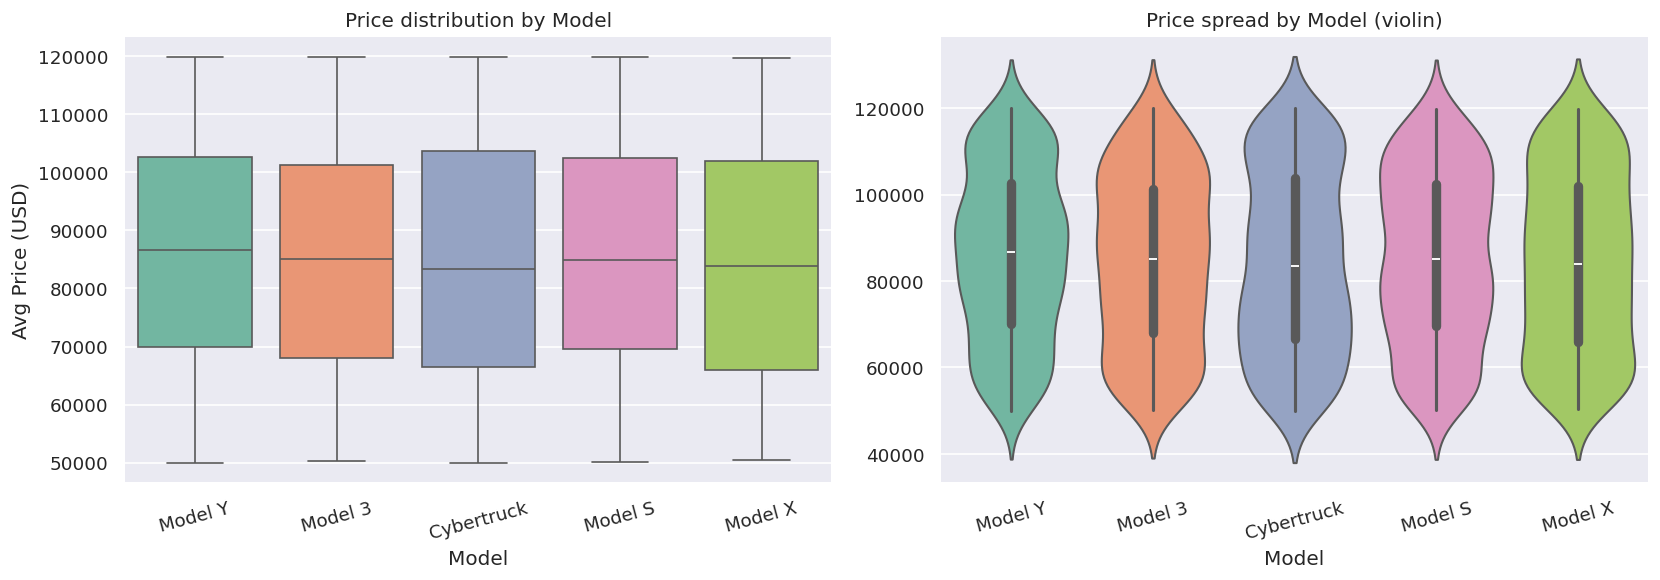

📌 Insight: Model S has highest price range, Model 3 is most affordable.


In [9]:
# ── 3.1 Price distribution by Model ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[0], palette="Set2")
axes[0].set_title("Price distribution by Model")
axes[0].set_ylabel("Avg Price (USD)")
axes[0].tick_params(axis='x', rotation=15)

# Violin plot
sns.violinplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[1], palette="Set2")
axes[1].set_title("Price spread by Model (violin)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print("📌 Insight: Model S has highest price range, Model 3 is most affordable.")

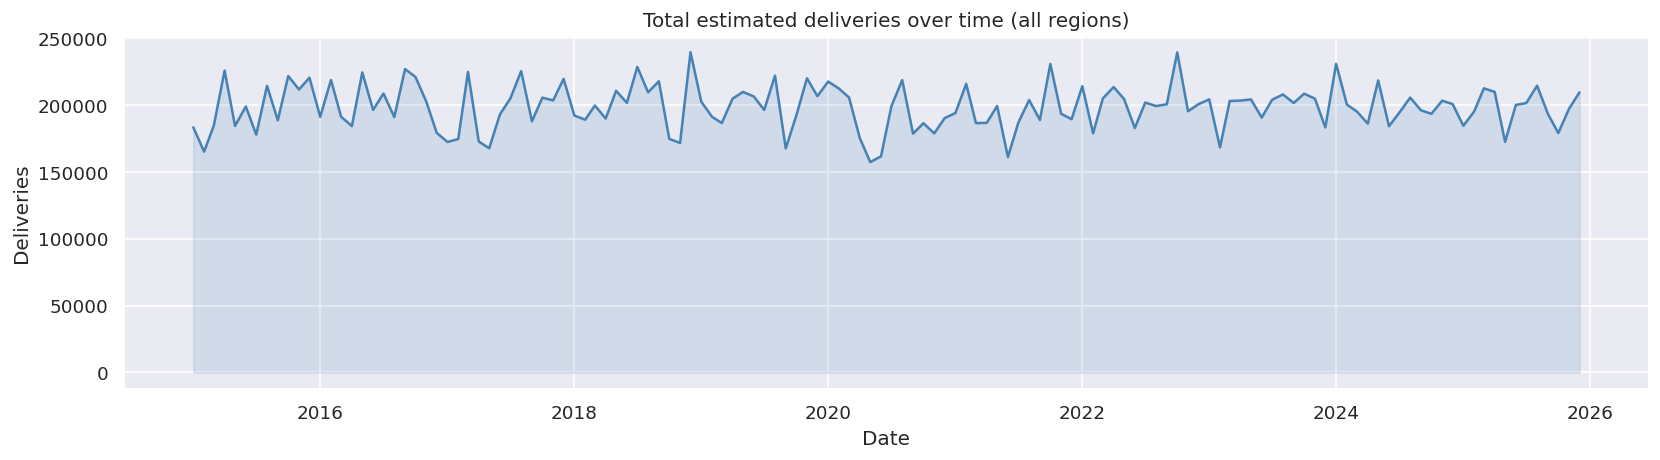

📌 Insight: Strong upward trend from 2015 to 2025 with seasonal spikes.


In [10]:
# ── 3.2 Monthly delivery trend (all regions combined) ─────────
monthly = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"], 
         color="steelblue", linewidth=1.5)
plt.fill_between(monthly["Date"], monthly["Estimated_Deliveries"], 
                 alpha=0.15, color="steelblue")
plt.title("Total estimated deliveries over time (all regions)")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.tight_layout()
plt.show()
print("📌 Insight: Strong upward trend from 2015 to 2025 with seasonal spikes.")

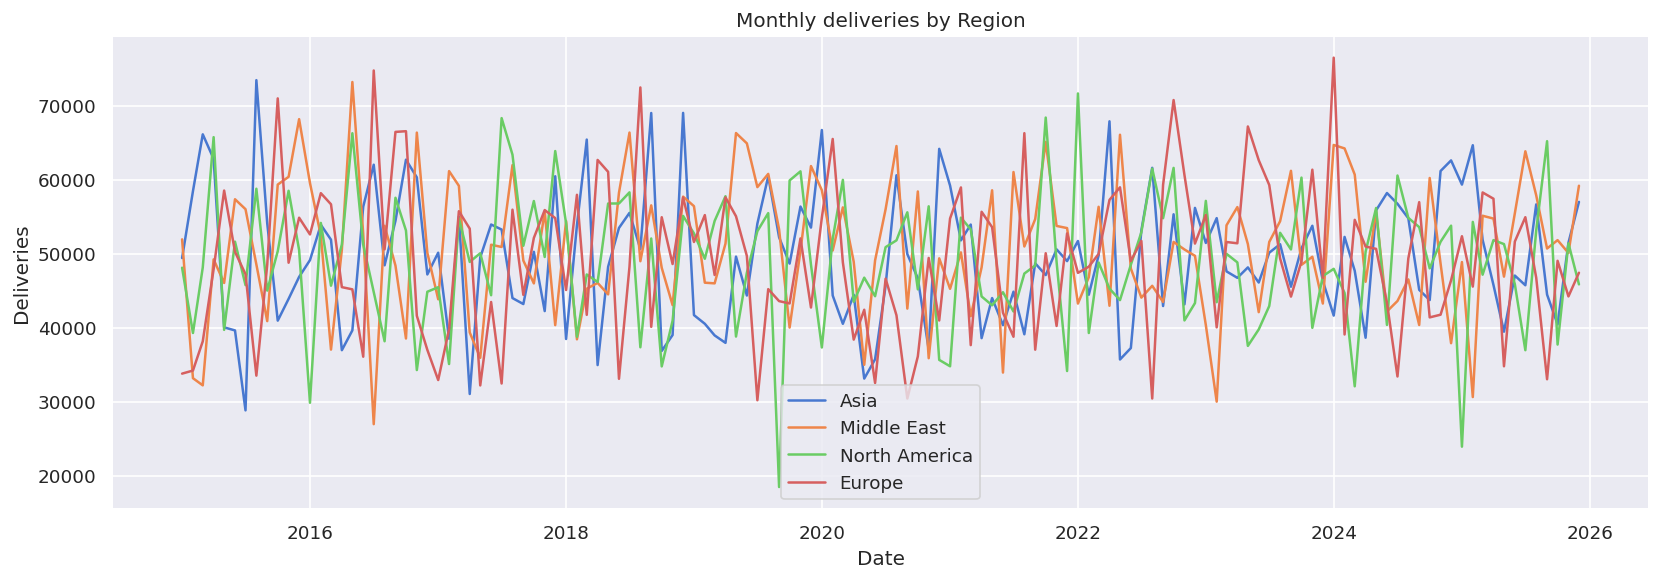

📌 Insight: North America and Europe are the top delivery regions.


In [11]:
# ── 3.3 Deliveries by Region over time ───────────────────────
region_monthly = df.groupby(["Date", "Region"])["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(14, 5))
for region in df["Region"].unique():
    subset = region_monthly[region_monthly["Region"] == region]
    plt.plot(subset["Date"], subset["Estimated_Deliveries"], 
             label=region, linewidth=1.5)

plt.title("Monthly deliveries by Region")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.tight_layout()
plt.show()
print("📌 Insight: North America and Europe are the top delivery regions.")

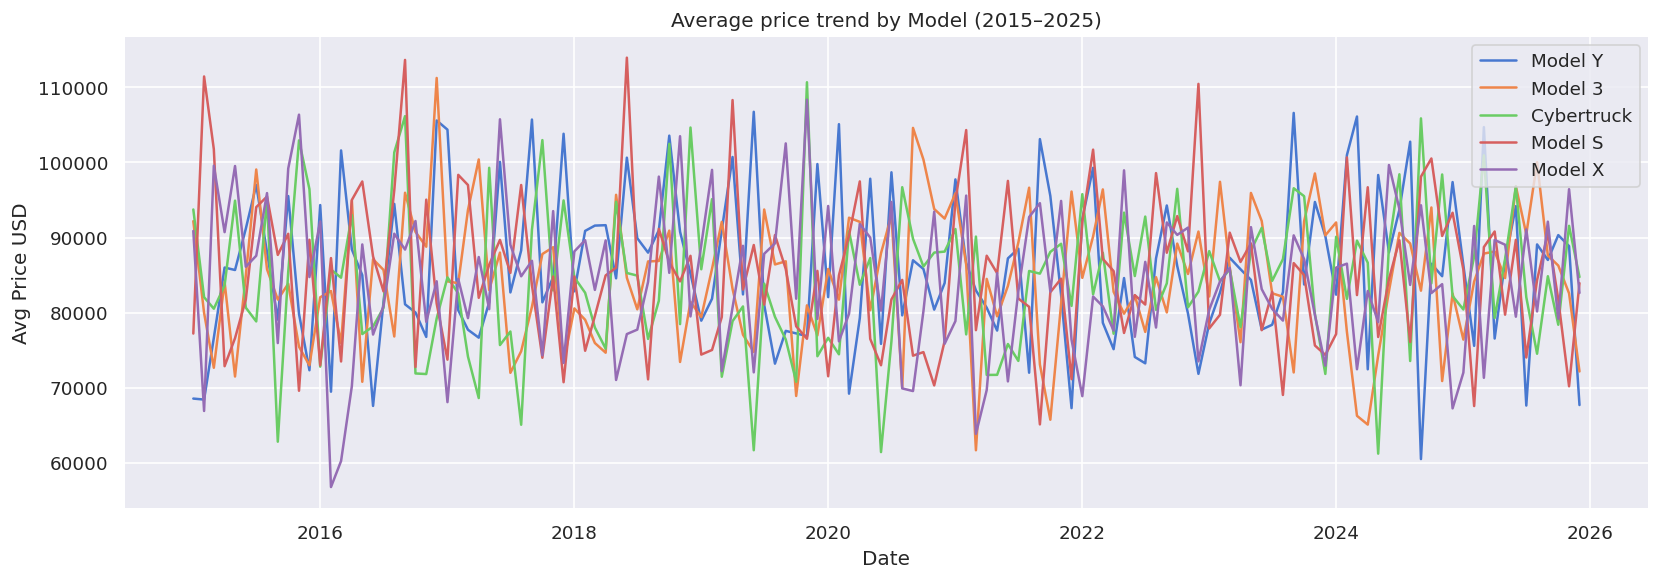

📌 Insight: All models show gradual price changes over the years.


In [12]:
# ── 3.4 Avg Price trend over time by Model ───────────────────
price_monthly = df.groupby(["Date", "Model"])["Avg_Price_USD"].mean().reset_index()

plt.figure(figsize=(14, 5))
for model in df["Model"].unique():
    subset = price_monthly[price_monthly["Model"] == model]
    plt.plot(subset["Date"], subset["Avg_Price_USD"], 
             label=model, linewidth=1.5)

plt.title("Average price trend by Model (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Avg Price USD")
plt.legend()
plt.tight_layout()
plt.show()
print("📌 Insight: All models show gradual price changes over the years.")

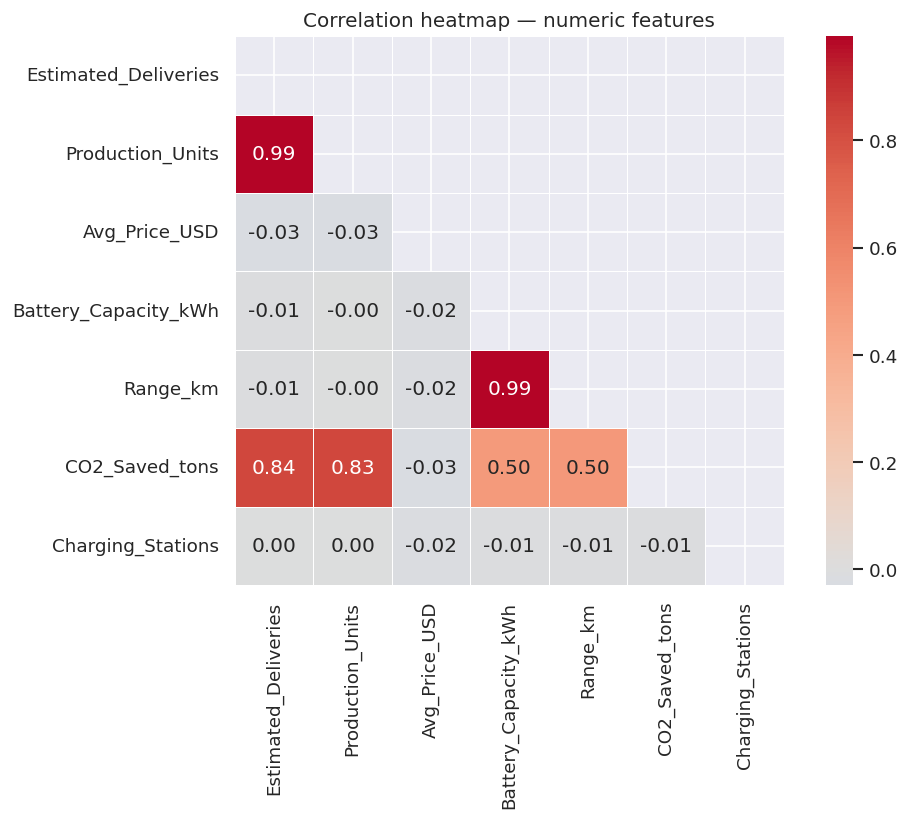

📌 Insight: Production & Deliveries are highly correlated (>0.99).


In [13]:
# ── 3.5 Correlation heatmap ───────────────────────────────────
num_cols = [
    "Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"
]

plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()
print("📌 Insight: Production & Deliveries are highly correlated (>0.99).")

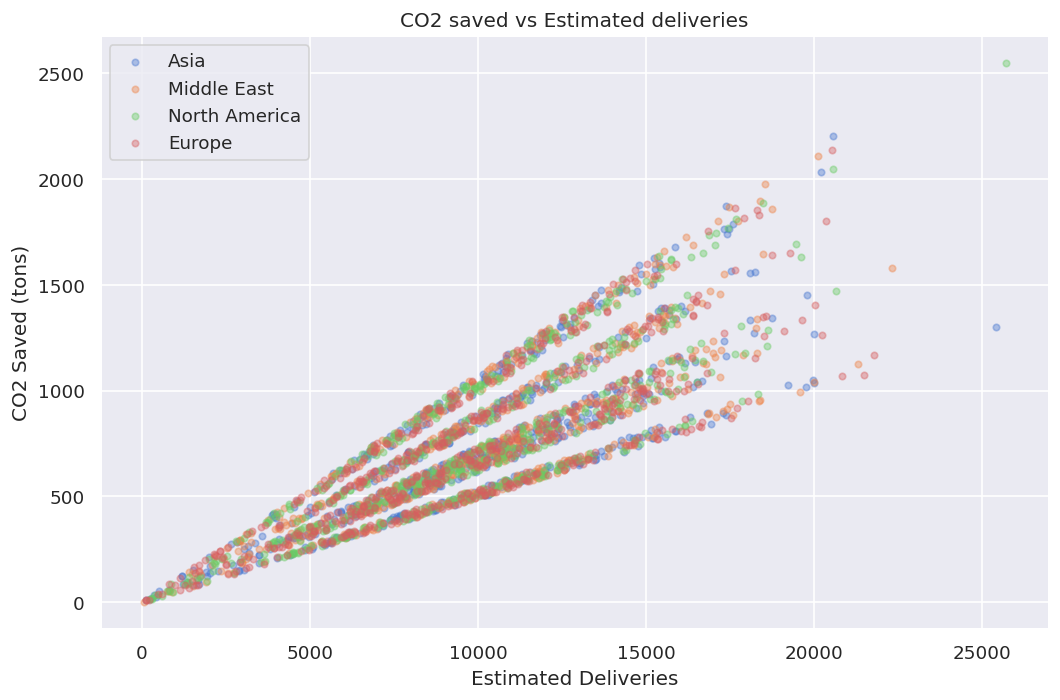

📌 Insight: Higher deliveries directly lead to more CO2 savings across all regions.


In [14]:
# ── 3.6 CO2 Saved vs Deliveries (colored by Region) ──────────
plt.figure(figsize=(9, 6))
for region in df["Region"].unique():
    subset = df[df["Region"] == region]
    plt.scatter(subset["Estimated_Deliveries"], subset["CO2_Saved_tons"],
                label=region, alpha=0.4, s=15)

plt.title("CO2 saved vs Estimated deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("CO2 Saved (tons)")
plt.legend()
plt.tight_layout()
plt.show()
print("📌 Insight: Higher deliveries directly lead to more CO2 savings across all regions.")

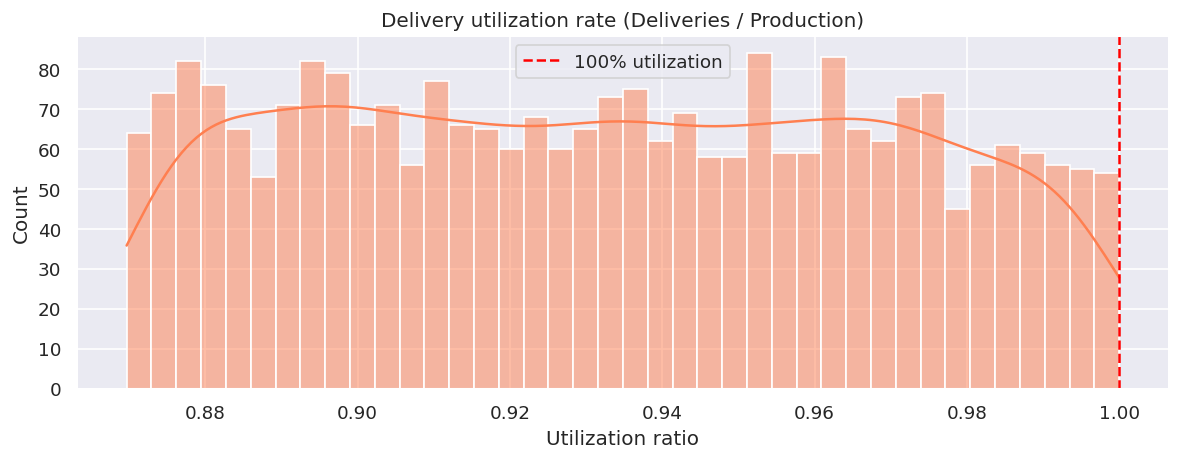

Mean utilization: 0.933
Rows > 100% utilization: 0
📌 Insight: Most utilization rates are below 1 — Tesla produces slightly more than it delivers.


In [15]:
# ── 3.7 Deliveries vs Production gap (utilization check) ─────
df["Utilization"] = df["Estimated_Deliveries"] / df["Production_Units"]

plt.figure(figsize=(10, 4))
sns.histplot(df["Utilization"], bins=40, kde=True, color="coral")
plt.axvline(1.0, color="red", linestyle="--", label="100% utilization")
plt.title("Delivery utilization rate (Deliveries / Production)")
plt.xlabel("Utilization ratio")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean utilization: {df['Utilization'].mean():.3f}")
print(f"Rows > 100% utilization: {(df['Utilization'] > 1).sum()}")
print("📌 Insight: Most utilization rates are below 1 — Tesla produces slightly more than it delivers.")

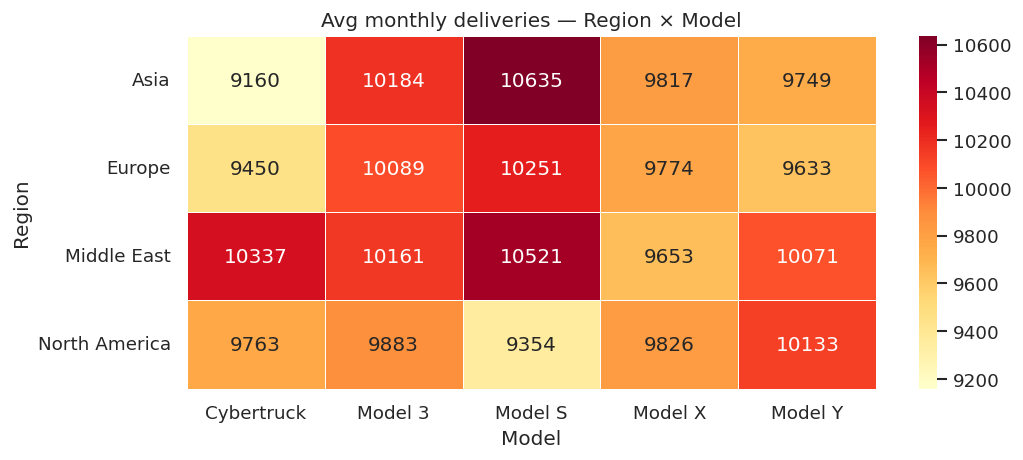

In [16]:
pivot = df.pivot_table(values="Estimated_Deliveries", index="Region", columns="Model", aggfunc="mean").round(0)
plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Avg monthly deliveries — Region × Model")
plt.tight_layout()
plt.show()

In [17]:
df["Price_per_kWh"] = df["Avg_Price_USD"] / df["Battery_Capacity_kWh"]
df["CO2_per_Delivery"] = df["CO2_Saved_tons"] / df["Estimated_Deliveries"]
df["Range_per_kWh"] = df["Range_km"] / df["Battery_Capacity_kWh"]
df["Charging_per_1k_Del"] = df["Charging_Stations"] / (df["Estimated_Deliveries"] / 1000)
df["Quarter"] = df["Date"].dt.quarter
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["Year_norm"] = (df["Year"] - df["Year"].min()) / (df["Year"].max() - df["Year"].min())
df["Is_Q_end"] = df["Month"].isin([3, 6, 9, 12]).astype(int)
print("✅ Ratio & time features added!")

✅ Ratio & time features added!


In [18]:
df = df.sort_values(["Region","Model","Date"]).reset_index(drop=True)
grp = df.groupby(["Region","Model"])
df["Deliveries_lag1"] = grp["Estimated_Deliveries"].shift(1)
df["Deliveries_lag3"] = grp["Estimated_Deliveries"].shift(3)
df["Price_lag1"] = grp["Avg_Price_USD"].shift(1)
df["Price_lag3"] = grp["Avg_Price_USD"].shift(3)
print("✅ Lag features added!")
df[["Region","Model","Date","Estimated_Deliveries","Deliveries_lag1"]].head(8)

✅ Lag features added!


,Region,Model,Date,Estimated_Deliveries,Deliveries_lag1
0,Asia,Cybertruck,2015-01-01,11325,NaN
1,Asia,Cybertruck,2015-02-01,13254,11325.0
2,Asia,Cybertruck,2015-03-01,10257,13254.0
3,Asia,Cybertruck,2015-04-01,15221,10257.0
4,Asia,Cybertruck,2015-05-01,6406,15221.0
5,Asia,Cybertruck,2015-06-01,7201,6406.0
6,Asia,Cybertruck,2015-07-01,113,7201.0
7,Asia,Cybertruck,2015-08-01,10222,113.0


In [19]:
df["Deliveries_roll3"] = grp["Estimated_Deliveries"].transform(lambda x: x.shift(1).rolling(3).mean())
df["Deliveries_roll6"] = grp["Estimated_Deliveries"].transform(lambda x: x.shift(1).rolling(6).mean())
df["Price_roll3"] = grp["Avg_Price_USD"].transform(lambda x: x.shift(1).rolling(3).mean())
print("✅ Rolling features added!")

✅ Rolling features added!


In [20]:
region_stats = df.groupby(["Region","Date"]).agg(
    Region_Total_Deliveries=("Estimated_Deliveries","sum"),
    Region_Avg_Price=("Avg_Price_USD","mean"),
    Region_Avg_CO2=("CO2_Saved_tons","mean")
).reset_index()
df = df.merge(region_stats, on=["Region","Date"], how="left")
df["Model_Market_Share"] = df["Estimated_Deliveries"] / df["Region_Total_Deliveries"]
print("✅ Region aggregate features added!")

✅ Region aggregate features added!


In [21]:
df_model = df.dropna(subset=["Deliveries_lag1","Deliveries_roll6","Price_lag1"]).reset_index(drop=True)
print(f"Rows before: {len(df)} | Rows after: {len(df_model)}")
feature_cols = [
    "Battery_Capacity_kWh","Range_km","Charging_Stations","Source_Type_enc",
    "Region_enc","Model_enc","Price_per_kWh","CO2_per_Delivery","Range_per_kWh",
    "Charging_per_1k_Del","Utilization","Year_norm","Month_sin","Month_cos",
    "Quarter","Is_Q_end","Deliveries_lag1","Deliveries_lag3","Price_lag1",
    "Price_lag3","Deliveries_roll3","Deliveries_roll6","Price_roll3",
    "Region_Total_Deliveries","Region_Avg_Price","Model_Market_Share"
]
print(f"Total features: {len(feature_cols)}")

Rows before: 2640 | Rows after: 2520
Total features: 26


In [22]:
!pip install xgboost -q
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("✅ XGBoost ready!")

✅ XGBoost ready!


In [23]:
X = df_model[feature_cols]
y_price = df_model["Avg_Price_USD"]
y_delivery = df_model["Estimated_Deliveries"]
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_price_train, y_price_test = y_price.iloc[:split_idx], y_price.iloc[split_idx:]
y_delivery_train, y_delivery_test = y_delivery.iloc[:split_idx], y_delivery.iloc[split_idx:]
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 2016 | Test: 504


In [24]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"  {name:<22} MAE={mae:>10.2f}  RMSE={rmse:>10.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

In [25]:
print("="*70)
print("TARGET: Avg_Price_USD")
print("="*70)
price_results = []
lr = LinearRegression()
lr.fit(X_train, y_price_train)
price_results.append(evaluate("Linear Regression", y_price_test, lr.predict(X_test)))
rf_price = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_price.fit(X_train, y_price_train)
price_results.append(evaluate("Random Forest", y_price_test, rf_price.predict(X_test)))
xgb_price = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0, n_jobs=-1)
xgb_price.fit(X_train, y_price_train, eval_set=[(X_test, y_price_test)], verbose=False)
price_results.append(evaluate("XGBoost", y_price_test, xgb_price.predict(X_test)))
price_df = pd.DataFrame(price_results).sort_values("R2", ascending=False)
print("\nBest model for price:", price_df.iloc[0]["Model"])

TARGET: Avg_Price_USD
  Linear Regression      MAE=   4720.91  RMSE=   5855.59  R²=0.9133  MAPE=5.78%
  Random Forest          MAE=    264.55  RMSE=    579.63  R²=0.9992  MAPE=0.34%
  XGBoost                MAE=    358.16  RMSE=    552.32  R²=0.9992  MAPE=0.46%

Best model for price: XGBoost


In [26]:
print("="*70)
print("TARGET: Estimated_Deliveries")
print("="*70)
del_results = []
lr2 = LinearRegression()
lr2.fit(X_train, y_delivery_train)
del_results.append(evaluate("Linear Regression", y_delivery_test, lr2.predict(X_test)))
rf_del = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_del.fit(X_train, y_delivery_train)
del_results.append(evaluate("Random Forest", y_delivery_test, rf_del.predict(X_test)))
xgb_del = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0, n_jobs=-1)
xgb_del.fit(X_train, y_delivery_train, eval_set=[(X_test, y_delivery_test)], verbose=False)
del_results.append(evaluate("XGBoost", y_delivery_test, xgb_del.predict(X_test)))
del_df = pd.DataFrame(del_results).sort_values("R2", ascending=False)
print("\nBest model for deliveries:", del_df.iloc[0]["Model"])

TARGET: Estimated_Deliveries
  Linear Regression      MAE=    440.38  RMSE=    734.19  R²=0.9644  MAPE=12.61%
  Random Forest          MAE=    160.94  RMSE=    486.89  R²=0.9843  MAPE=2.67%
  XGBoost                MAE=    151.96  RMSE=    447.64  R²=0.9868  MAPE=2.40%

Best model for deliveries: XGBoost


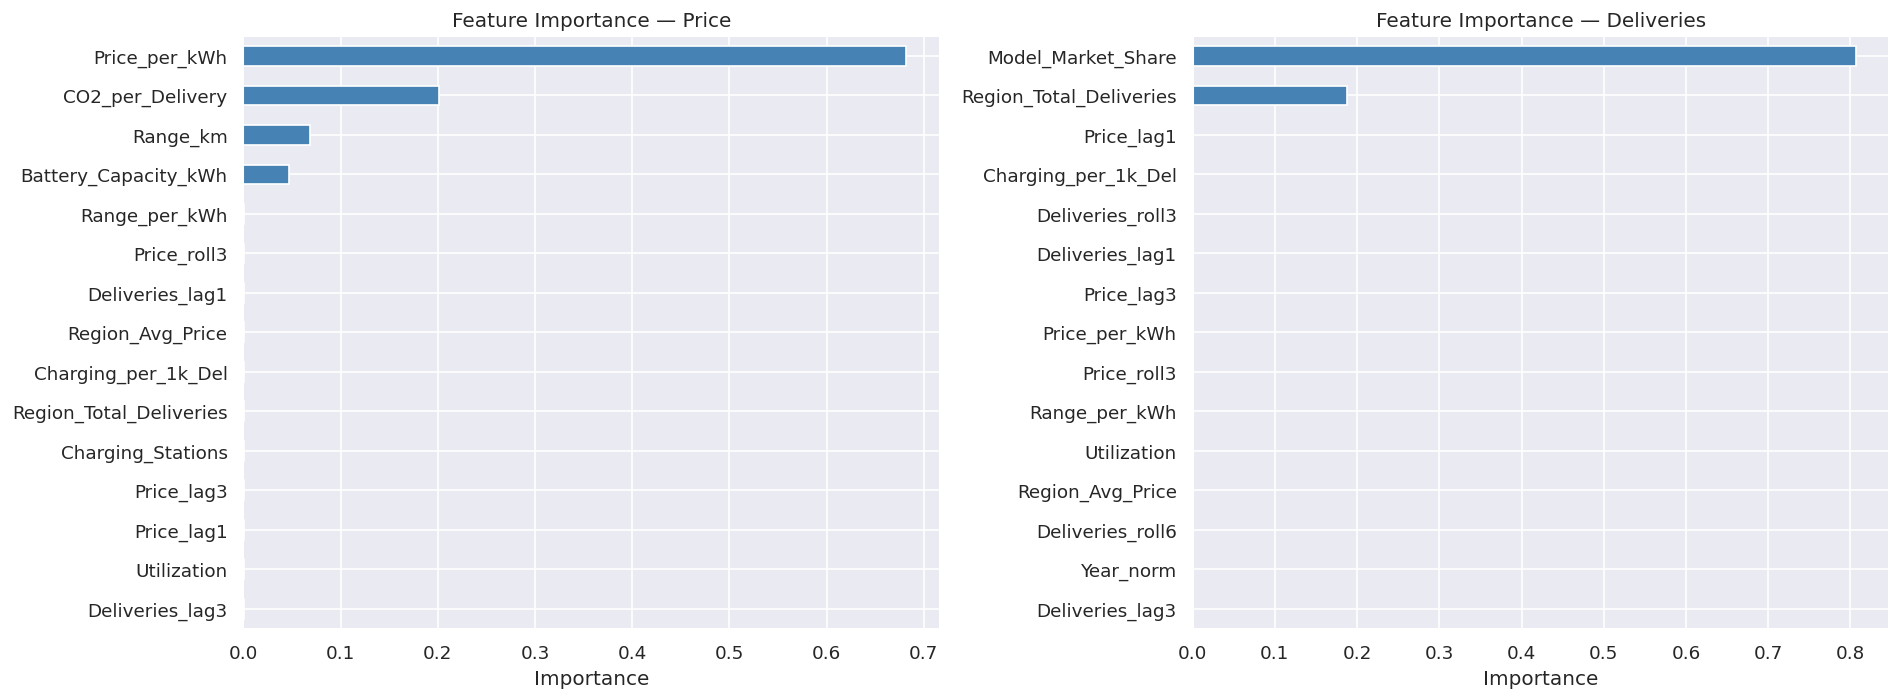

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, title in zip(axes, [rf_price, rf_del], ["Feature Importance — Price", "Feature Importance — Deliveries"]):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances.sort_values().tail(15).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.5),
    "reg_alpha": uniform(0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}
tscv = KFold(n_splits=5, shuffle=False)
print("✅ Tuning setup ready!")

✅ Tuning setup ready!


In [29]:
print("Tuning XGBoost for Avg_Price_USD ...")
xgb_price_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
search_price = RandomizedSearchCV(xgb_price_base, param_distributions=param_dist, n_iter=40, scoring="neg_root_mean_squared_error", cv=tscv, random_state=42, n_jobs=-1, verbose=1)
search_price.fit(X_train, y_price_train)
print("\nBest params (Price):")
for k, v in search_price.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {-search_price.best_score_:.2f}")

Tuning XGBoost for Avg_Price_USD ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params (Price):
  colsample_bytree: 0.9895022075365837
  gamma: 0.11638567021515211
  learning_rate: 0.02812128690656416
  max_depth: 8
  min_child_weight: 3
  n_estimators: 463
  reg_alpha: 0.5142344384136116
  reg_lambda: 1.684829137724085
  subsample: 0.6185801650879991
Best CV RMSE: 803.51


In [30]:
print("Tuning XGBoost for Estimated_Deliveries ...")
xgb_del_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
search_del = RandomizedSearchCV(xgb_del_base, param_distributions=param_dist, n_iter=40, scoring="neg_root_mean_squared_error", cv=tscv, random_state=42, n_jobs=-1, verbose=1)
search_del.fit(X_train, y_delivery_train)
print("\nBest params (Deliveries):")
for k, v in search_del.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {-search_del.best_score_:.2f}")

Tuning XGBoost for Estimated_Deliveries ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params (Deliveries):
  colsample_bytree: 0.9895022075365837
  gamma: 0.11638567021515211
  learning_rate: 0.02812128690656416
  max_depth: 8
  min_child_weight: 3
  n_estimators: 463
  reg_alpha: 0.5142344384136116
  reg_lambda: 1.684829137724085
  subsample: 0.6185801650879991
Best CV RMSE: 222.92


In [31]:
print("="*65)
print("BEFORE vs AFTER TUNING — Avg_Price_USD")
print("="*65)
evaluate("XGBoost (default)", y_price_test, xgb_price.predict(X_test))
best_price_pred = search_price.best_estimator_.predict(X_test)
evaluate("XGBoost (tuned)", y_price_test, best_price_pred)
print("\n"+"="*65)
print("BEFORE vs AFTER TUNING — Estimated_Deliveries")
print("="*65)
evaluate("XGBoost (default)", y_delivery_test, xgb_del.predict(X_test))
best_del_pred = search_del.best_estimator_.predict(X_test)
evaluate("XGBoost (tuned)", y_delivery_test, best_del_pred)

BEFORE vs AFTER TUNING — Avg_Price_USD
  XGBoost (default)      MAE=    358.16  RMSE=    552.32  R²=0.9992  MAPE=0.46%
  XGBoost (tuned)        MAE=    480.60  RMSE=    632.26  R²=0.9990  MAPE=0.62%

BEFORE vs AFTER TUNING — Estimated_Deliveries
  XGBoost (default)      MAE=    151.96  RMSE=    447.64  R²=0.9868  MAPE=2.40%
  XGBoost (tuned)        MAE=    125.56  RMSE=    386.06  R²=0.9902  MAPE=2.00%


{'Model': 'XGBoost (tuned)',
 'MAE': 125.55618286132812,
 'RMSE': np.float64(386.06160454000087),
 'R2': 0.9901567697525024,
 'MAPE': np.float64(1.9991579050085213)}

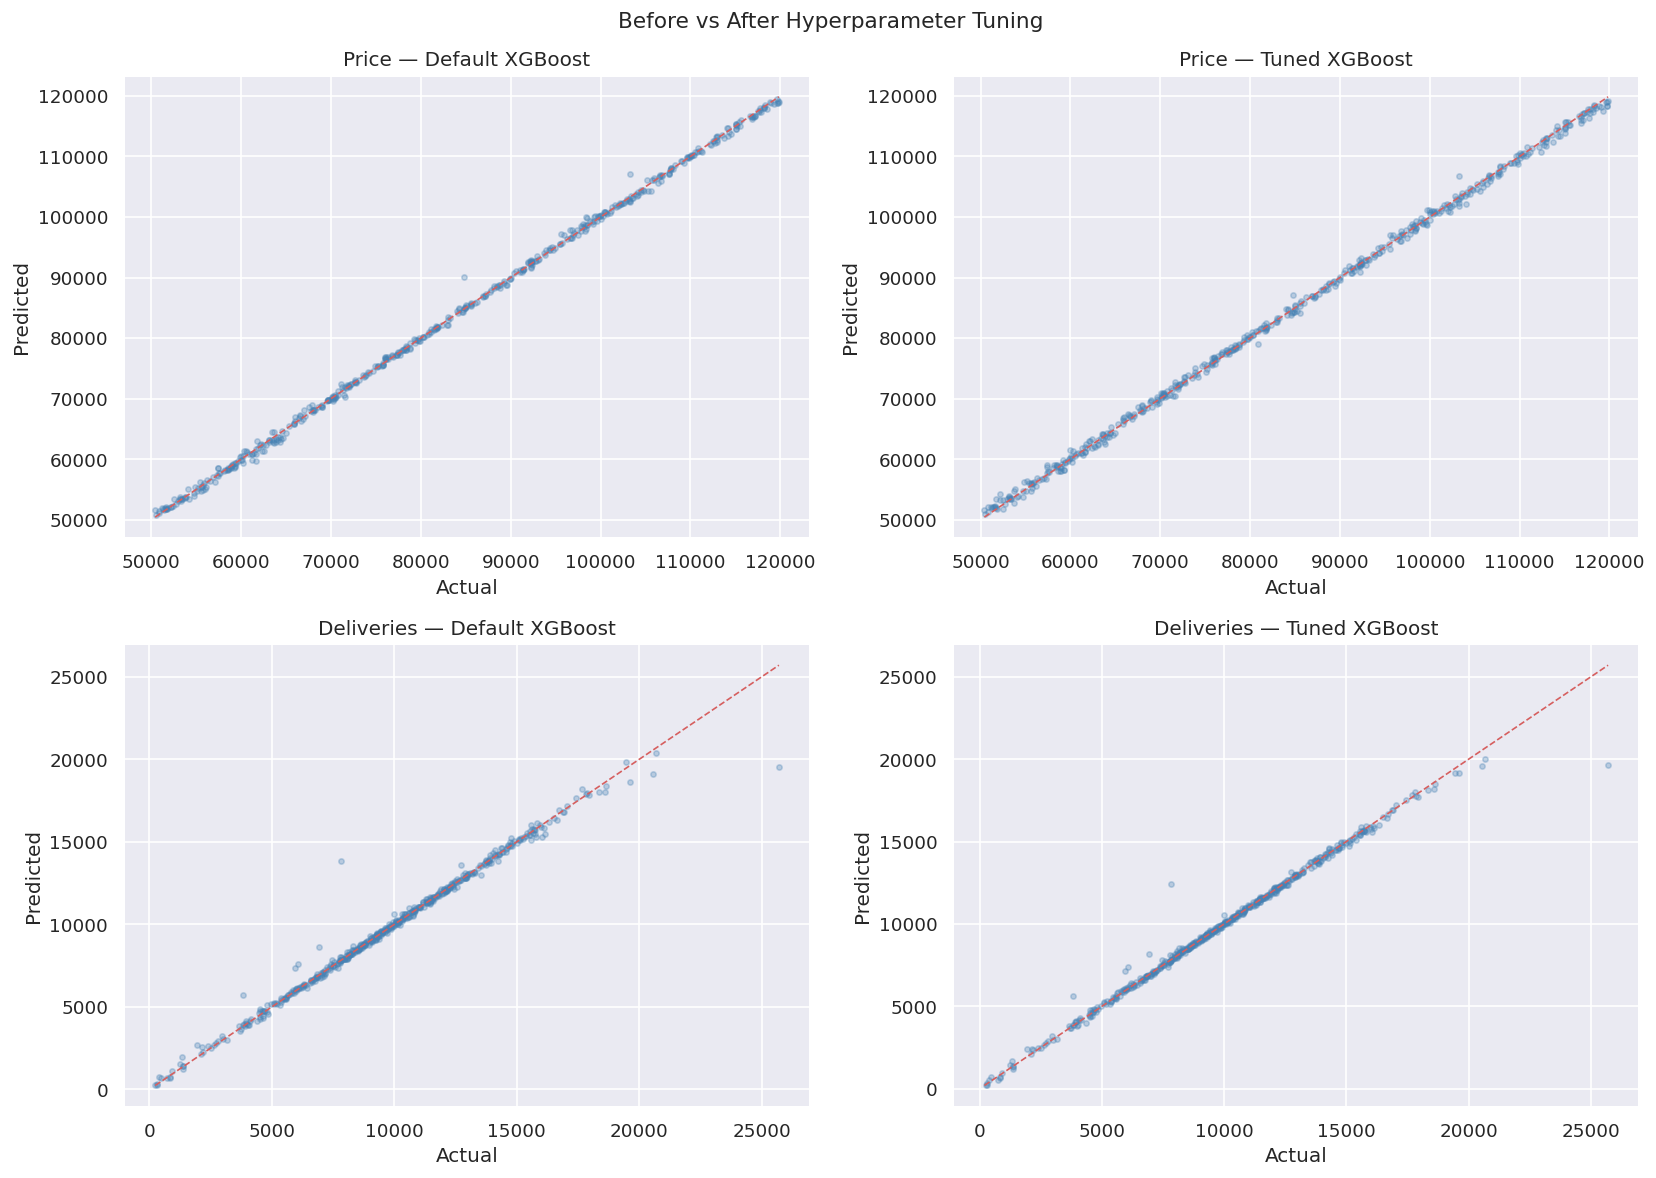

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [
    (xgb_price.predict(X_test), y_price_test, "Price — Default XGBoost", axes[0][0]),
    (best_price_pred, y_price_test, "Price — Tuned XGBoost", axes[0][1]),
    (xgb_del.predict(X_test), y_delivery_test, "Deliveries — Default XGBoost", axes[1][0]),
    (best_del_pred, y_delivery_test, "Deliveries — Tuned XGBoost", axes[1][1]),
]
for preds, y_true, title, ax in pairs:
    ax.scatter(y_true, preds, alpha=0.3, s=10, color="steelblue")
    lims = [min(y_true.min(), preds.min()), max(y_true.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
plt.suptitle("Before vs After Hyperparameter Tuning", fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
!pip install prophet -q
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")
print("✅ Prophet & SARIMA ready!")

✅ Prophet & SARIMA ready!


In [34]:
ts_del = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()
ts_price = df.groupby("Date")["Avg_Price_USD"].mean().reset_index()
ts_del = ts_del.set_index("Date").asfreq("MS")
ts_price = ts_price.set_index("Date").asfreq("MS")
print("Delivery series shape:", ts_del.shape)
print("Price series shape:", ts_price.shape)
ts_del.tail(3)

Delivery series shape: (132, 1)
Price series shape: (132, 1)


,Estimated_Deliveries
Date,
2025-10-01,178964
2025-11-01,197146
2025-12-01,209391


In [35]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    p = result[1]
    print(f"{name}: ADF stat={result[0]:.4f}, p-value={p:.4f} → {'✅ Stationary' if p < 0.05 else '⚠️ Non-stationary'}")

adf_test(ts_del["Estimated_Deliveries"], "Deliveries")
adf_test(ts_price["Avg_Price_USD"], "Avg Price")

Deliveries: ADF stat=-8.8810, p-value=0.0000 → ✅ Stationary
Avg Price: ADF stat=-9.8870, p-value=0.0000 → ✅ Stationary


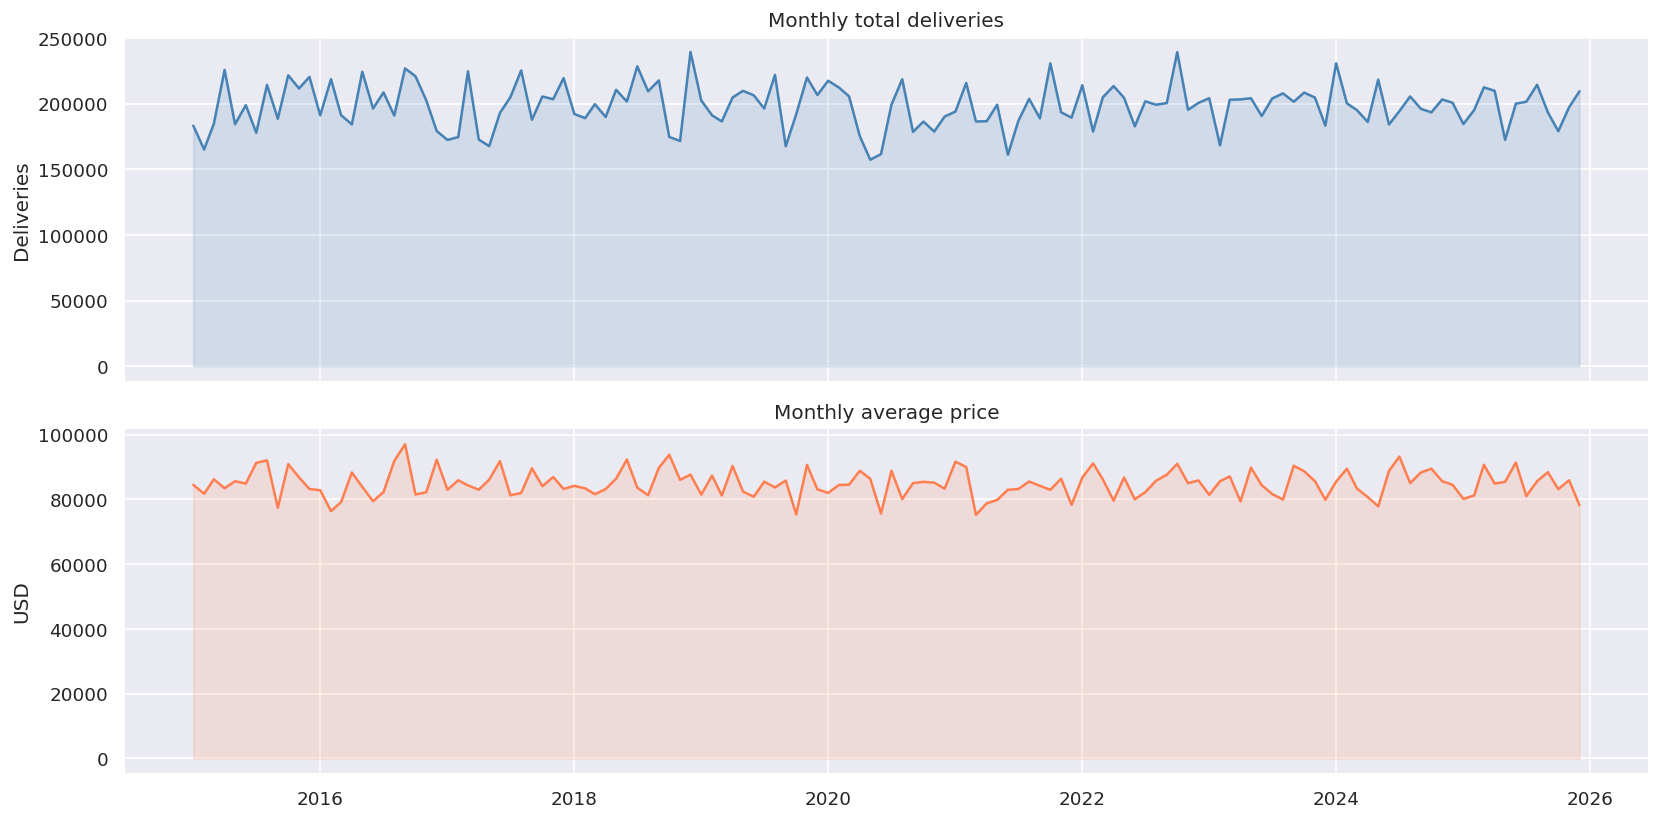

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(ts_del.index, ts_del["Estimated_Deliveries"], color="steelblue", linewidth=1.5)
axes[0].fill_between(ts_del.index, ts_del["Estimated_Deliveries"], alpha=0.15, color="steelblue")
axes[0].set_title("Monthly total deliveries")
axes[0].set_ylabel("Deliveries")
axes[1].plot(ts_price.index, ts_price["Avg_Price_USD"], color="coral", linewidth=1.5)
axes[1].fill_between(ts_price.index, ts_price["Avg_Price_USD"], alpha=0.15, color="coral")
axes[1].set_title("Monthly average price")
axes[1].set_ylabel("USD")
plt.tight_layout()
plt.show()

In [37]:
FORECAST_MONTHS = 12
train_del = ts_del.iloc[:-FORECAST_MONTHS]
test_del = ts_del.iloc[-FORECAST_MONTHS:]
train_price = ts_price.iloc[:-FORECAST_MONTHS]
test_price = ts_price.iloc[-FORECAST_MONTHS:]
print(f"Train: {train_del.index[0].date()} → {train_del.index[-1].date()}")
print(f"Test:  {test_del.index[0].date()} → {test_del.index[-1].date()}")

Train: 2015-01-01 → 2024-12-01
Test:  2025-01-01 → 2025-12-01


In [38]:
sarima_del = SARIMAX(train_del["Estimated_Deliveries"], order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
sarima_del_fit = sarima_del.fit(disp=False)
print(sarima_del_fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1061.796
Date:                            Fri, 29 May 2026   AIC                           2133.592
Time:                                    10:16:12   BIC                           2146.255
Sample:                                01-01-2015   HQIC                          2138.705
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         


In [39]:
sarima_price = SARIMAX(train_price["Avg_Price_USD"], order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
sarima_price_fit = sarima_price.fit(disp=False)
print(sarima_price_fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                      Avg_Price_USD   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -935.534
Date:                            Fri, 29 May 2026   AIC                           1881.068
Time:                                    10:16:12   BIC                           1893.731
Sample:                                01-01-2015   HQIC                          1886.181
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         


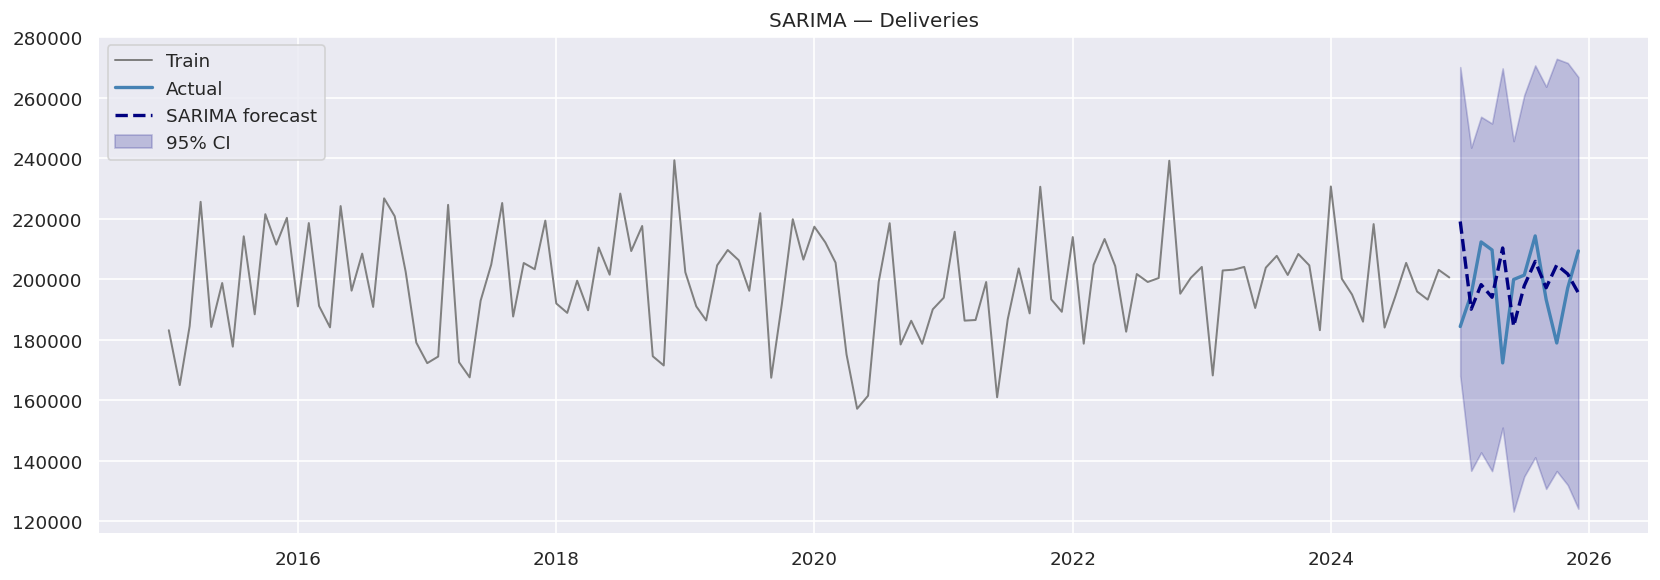

SARIMA MAPE (SARIMA — Deliveries): 8.02%


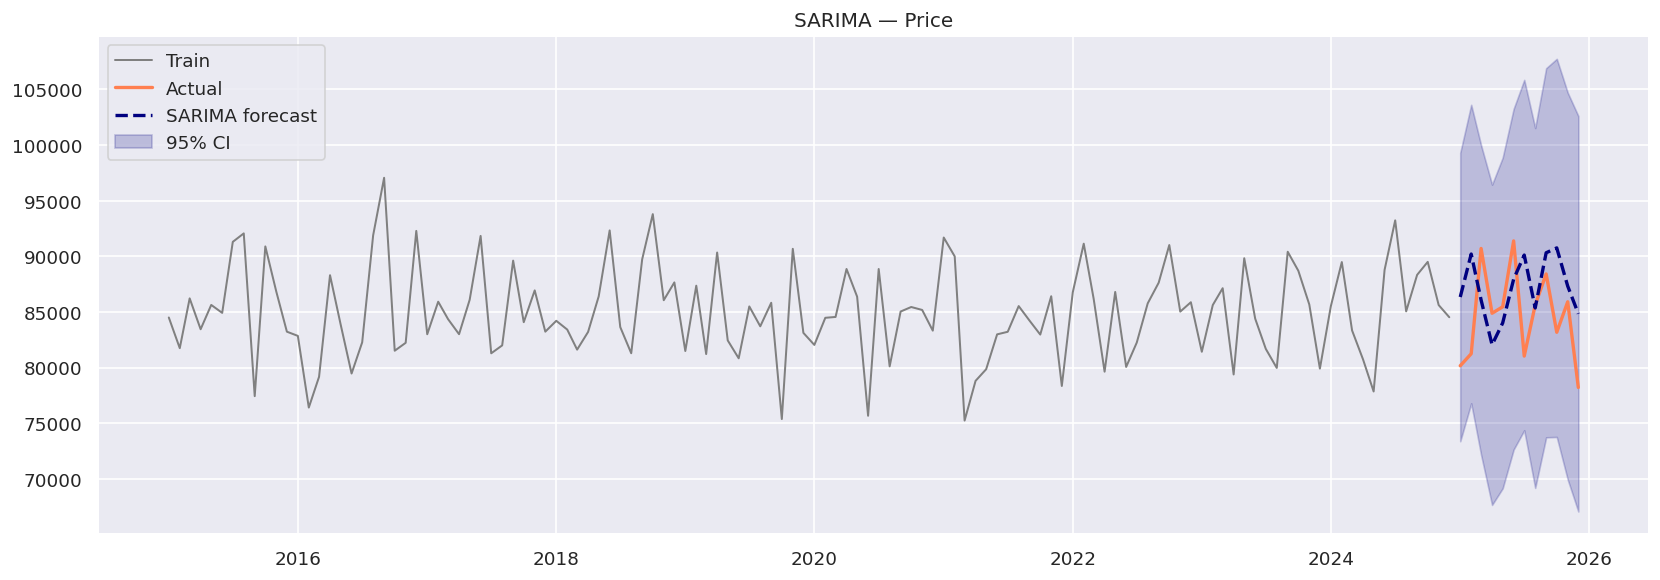

SARIMA MAPE (SARIMA — Price): 5.46%


In [40]:
def plot_sarima(fit, train, test, title, color):
    forecast = fit.get_forecast(steps=FORECAST_MONTHS)
    pred_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()
    plt.figure(figsize=(14, 5))
    plt.plot(train.index, train.iloc[:,0], label="Train", color="gray", linewidth=1.2)
    plt.plot(test.index, test.iloc[:,0], label="Actual", color=color, linewidth=2)
    plt.plot(pred_mean.index, pred_mean, label="SARIMA forecast", color="navy", linewidth=2, linestyle="--")
    plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2, color="navy", label="95% CI")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    mape = np.mean(np.abs((test.iloc[:,0].values - pred_mean.values) / test.iloc[:,0].values)) * 100
    print(f"SARIMA MAPE ({title}): {mape:.2f}%")
    return pred_mean

sarima_del_forecast = plot_sarima(sarima_del_fit, train_del, test_del, "SARIMA — Deliveries", "steelblue")
sarima_price_forecast = plot_sarima(sarima_price_fit, train_price, test_price, "SARIMA — Price", "coral")

10:16:14 - cmdstanpy - INFO - Chain [1] start processing
10:16:14 - cmdstanpy - INFO - Chain [1] done processing


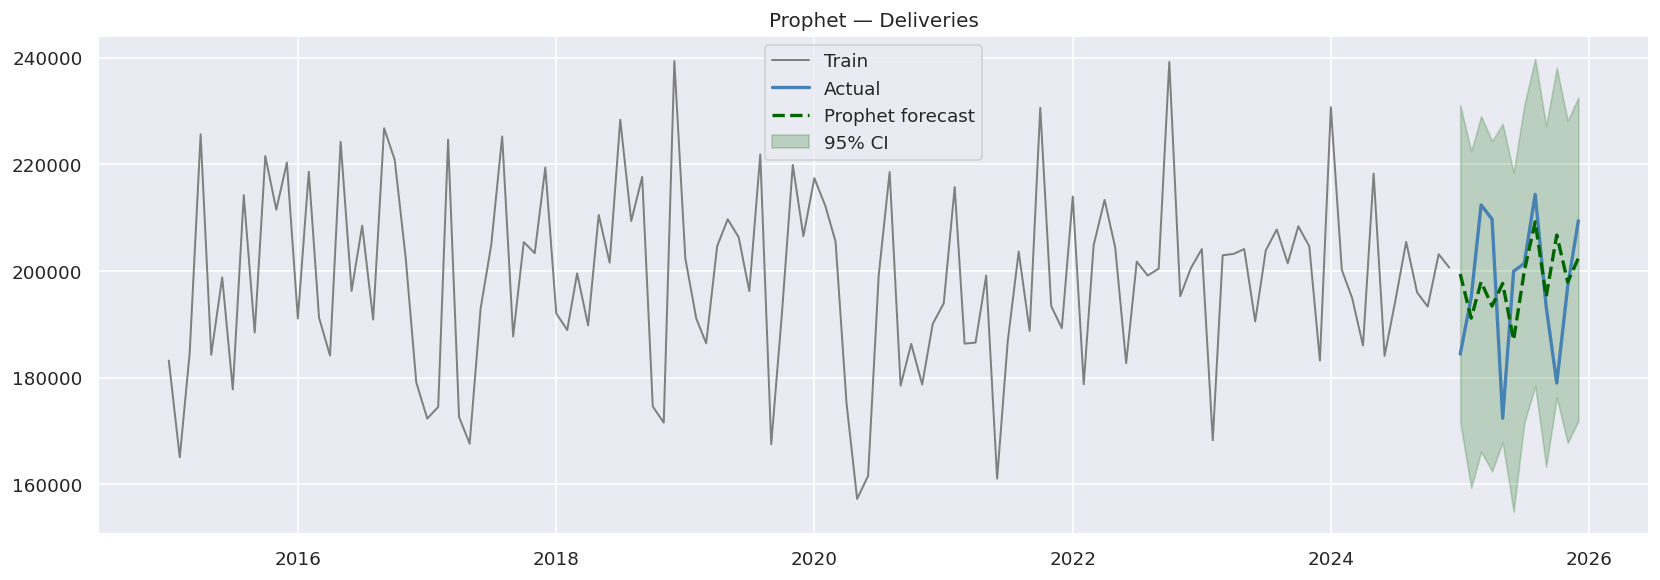

10:16:16 - cmdstanpy - INFO - Chain [1] start processing
10:16:16 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE (Prophet — Deliveries): 5.77%


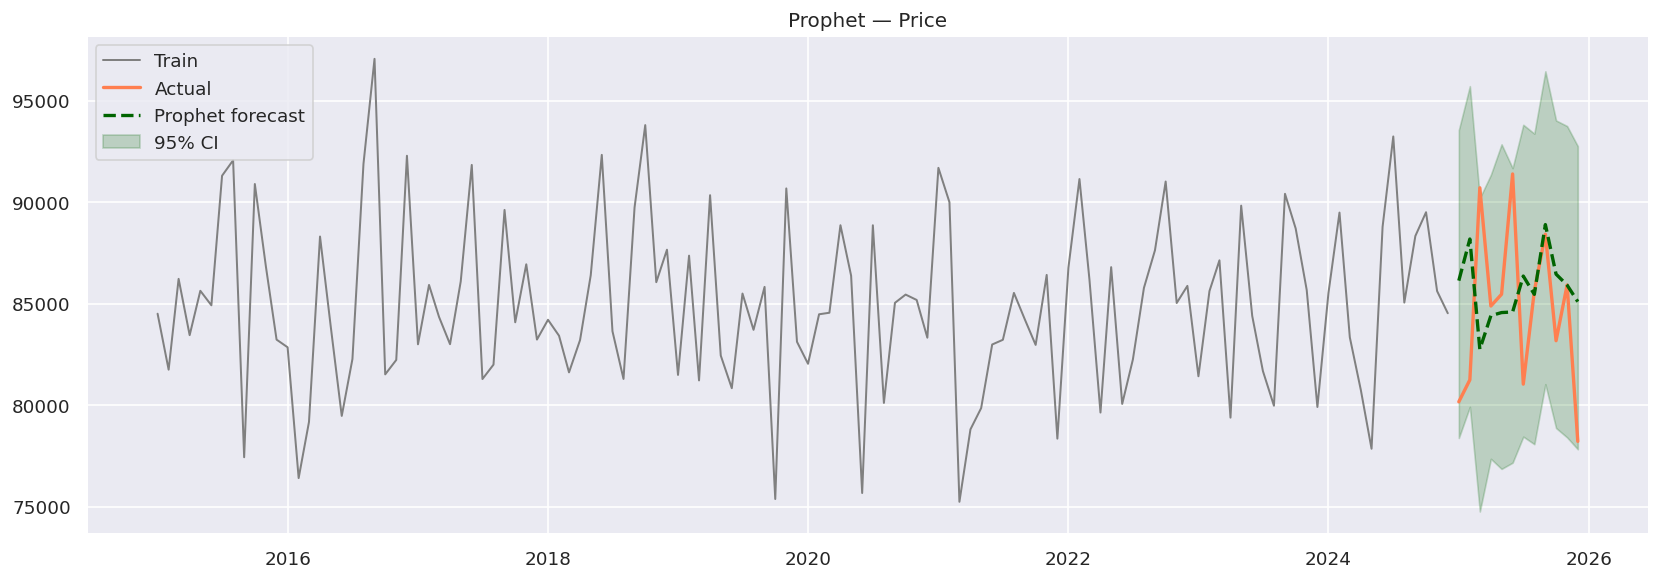

Prophet MAPE (Prophet — Price): 4.49%


In [41]:
def run_prophet(train, test, col, title, color):
    prophet_df = train.reset_index().rename(columns={"Date":"ds", col:"y"})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="multiplicative", interval_width=0.95)
    m.fit(prophet_df)
    future = m.make_future_dataframe(periods=FORECAST_MONTHS, freq="MS")
    forecast = m.predict(future)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train.index, train[col], label="Train", color="gray", linewidth=1.2)
    ax.plot(test.index, test[col], label="Actual", color=color, linewidth=2)
    fc_test = forecast.set_index("ds").loc[test.index]
    ax.plot(fc_test.index, fc_test["yhat"], label="Prophet forecast", color="darkgreen", linewidth=2, linestyle="--")
    ax.fill_between(fc_test.index, fc_test["yhat_lower"], fc_test["yhat_upper"], alpha=0.2, color="darkgreen", label="95% CI")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    mape = np.mean(np.abs((test[col].values - fc_test["yhat"].values) / test[col].values)) * 100
    print(f"Prophet MAPE ({title}): {mape:.2f}%")

run_prophet(train_del, test_del, "Estimated_Deliveries", "Prophet — Deliveries", "steelblue")
run_prophet(train_price, test_price, "Avg_Price_USD", "Prophet — Price", "coral")

In [42]:
print("📊 PRICE MODEL COMPARISON")
print(price_df.to_string(index=False))
print("\n📊 DELIVERY MODEL COMPARISON")
print(del_df.to_string(index=False))
best_price_model = search_price.best_estimator_
best_delivery_model = search_del.best_estimator_
print("\n✅ Best tuned models saved!")
print("🏆 Pipeline Complete!")

📊 PRICE MODEL COMPARISON
            Model         MAE        RMSE       R2     MAPE
          XGBoost  358.164914  552.316414 0.999228 0.457926
    Random Forest  264.547505  579.634340 0.999150 0.336726
Linear Regression 4720.908345 5855.588724 0.913277 5.778264

📊 DELIVERY MODEL COMPARISON
            Model        MAE       RMSE       R2      MAPE
          XGBoost 151.956161 447.643640 0.986766  2.402344
    Random Forest 160.936488 486.886642 0.984344  2.668525
Linear Regression 440.384315 734.186893 0.964401 12.609489

✅ Best tuned models saved!
🏆 Pipeline Complete!


In [43]:
# ── Predictions CSV save karo ─────────────────────────────────
results_df = X_test.copy()
results_df["Actual_Price"] = y_price_test.values
results_df["Predicted_Price"] = best_price_pred
results_df["Actual_Deliveries"] = y_delivery_test.values
results_df["Predicted_Deliveries"] = best_del_pred

# Save to Kaggle output folder
results_df.to_csv("/kaggle/working/predictions.csv", index=False)
df_model.to_csv("/kaggle/working/engineered_features.csv", index=False)

print("✅ Files saved!")
print("📁 predictions.csv — actual vs predicted")
print("📁 engineered_features.csv — all features used")

✅ Files saved!
📁 predictions.csv — actual vs predicted
📁 engineered_features.csv — all features used
